
Segment                N        Mean µSv/hr         Std µSv/hr
----------------------------------------------------------
Above Ground         417          0.0322         0.0163
Underground          690          0.0471         0.0222
Transbay Tunnel      131          0.0384         0.0163

Segment                N        Mean CPS         Std CPS
----------------------------------------------------------
Above Ground         417          2.5719         1.2966
Underground          690          3.7565         1.7723
Transbay Tunnel      131          3.0611         1.3039


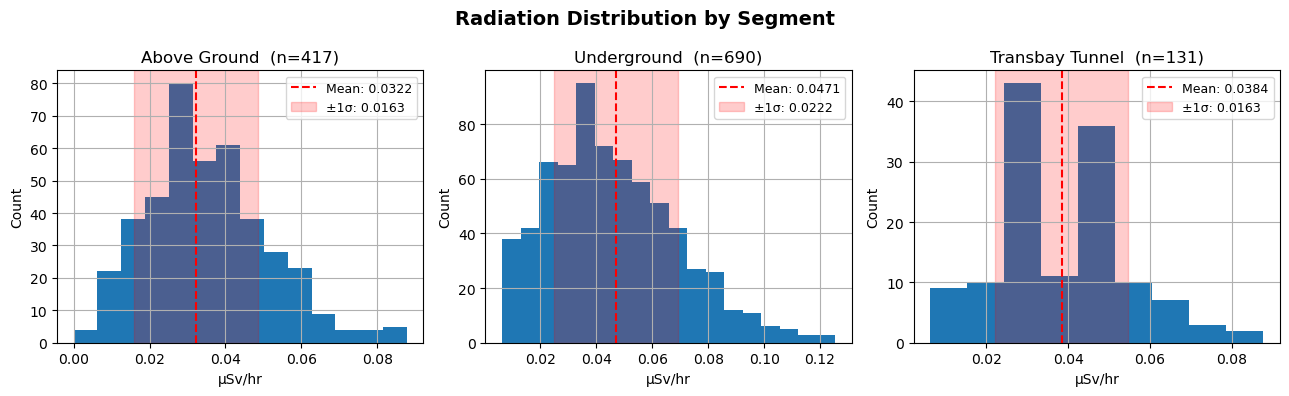

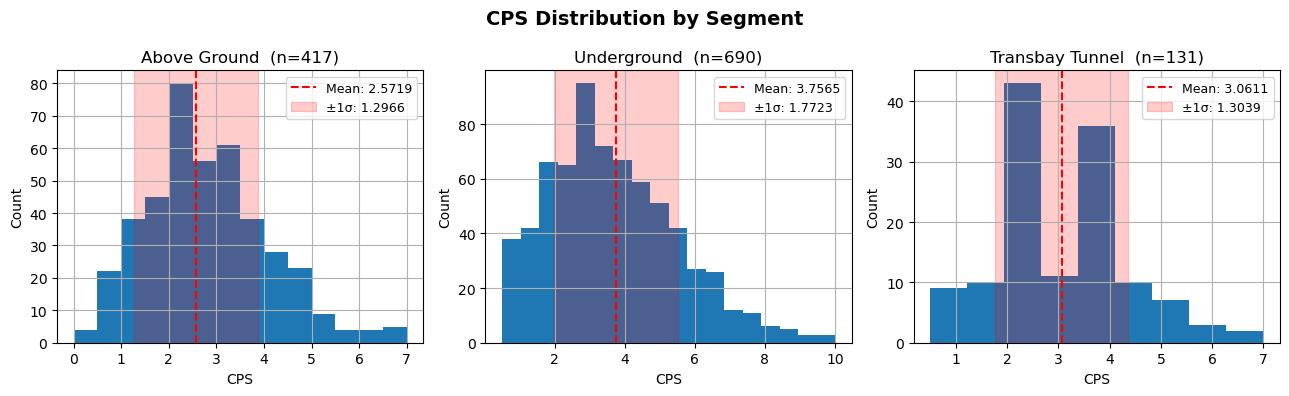

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime

# ── Setup ──────────────────────────────────────────────────────────────────────
t0 = 1777592470.0

def ts(h, m, s):
    base = datetime.datetime(2026, 4, 30, 16, 41, 10)
    return t0 + (datetime.datetime(2026, 4, 30, h, m, s) - base).total_seconds()

segments = [
    (ts(16,41,50), ts(16,44,35), "above"),
    (ts(16,44,35), ts(16,45,40), "underground"),
    (ts(16,45,40), ts(16,46,10), "above"),
    (ts(16,46,10), ts(17, 0,10), "underground"),
    (ts(17, 0,10), ts(17, 4,35), "transbay"),
    (ts(17, 4,35), ts(17, 9,34), "above"),
    (ts(17, 9,34), ts(17,14,10), "underground"),
    (ts(17,14,10), ts(17,19,20), "above"),
    (ts(17,19,21), ts(17,23, 0), "underground"),
]

def classify(t):
    for s, e, cat in segments:
        if s <= t < e:
            return cat
    return "above"

# ── Load & classify ────────────────────────────────────────────────────────────
rad = pd.read_csv("radiation.csv").sort_values("timestamp").reset_index(drop=True)
rad["segment"] = rad.timestamp.apply(classify)

# ── Stats ──────────────────────────────────────────────────────────────────────
labels = {"above": "Above Ground", "underground": "Underground", "transbay": "Transbay Tunnel"}
cats   = ["above", "underground", "transbay"]

for col, unit in [("usv_hr", "µSv/hr"), ("cps", "CPS")]:
    print(f"\n{'Segment':<18} {'N':>5}  {'Mean':>10} {unit}  {'Std':>10} {unit}")
    print("-" * 58)
    for cat in cats:
        sub = rad[rad.segment == cat][col]
        print(f"{labels[cat]:<18} {len(sub):>5}  {sub.mean():>14.4f}  {sub.std():>13.4f}")

# ── Histogram helper ───────────────────────────────────────────────────────────
def plot_hist_row(axes, col, xlabel):
    for ax, cat in zip(axes, cats):
        sub = rad[rad.segment == cat][col]
        mean, std = sub.mean(), sub.std()
        bins = 18 if cat == "underground" else 'auto'
        ax.hist(sub, bins=bins)
        ax.axvline(mean, color="red", linewidth=1.5, linestyle="--",
                   label=f"Mean: {mean:.4f}")
        ax.axvspan(mean - std, mean + std, alpha=0.2, color="red",
                   label=f"±1σ: {std:.4f}")
        ax.legend(fontsize=9)
        ax.grid()
        ax.set_title(f"{labels[cat]}  (n={len(sub)})")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Count")

# ── Figure 1: µSv/hr ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
fig.suptitle("Radiation Distribution by Segment", fontsize=14, fontweight="bold")
plot_hist_row(axes, "usv_hr", "µSv/hr")
plt.tight_layout()
plt.show()

# ── Figure 2: CPS ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
fig.suptitle("CPS Distribution by Segment", fontsize=14, fontweight="bold")
plot_hist_row(axes, "cps", "CPS")
plt.tight_layout()
plt.show()

# other segments

Air Quality stats:
Segment                  pm1_mean       pm25_mean       pm10_mean
----------------------------------------------------------------------
Above Ground         0.000 ± 0.000   0.000 ± 0.000   0.000 ± 0.000
Underground          0.000 ± 0.000   0.149 ± 0.629   0.166 ± 0.750
Transbay Tunnel      0.000 ± 0.000   0.000 ± 0.000   0.000 ± 0.000


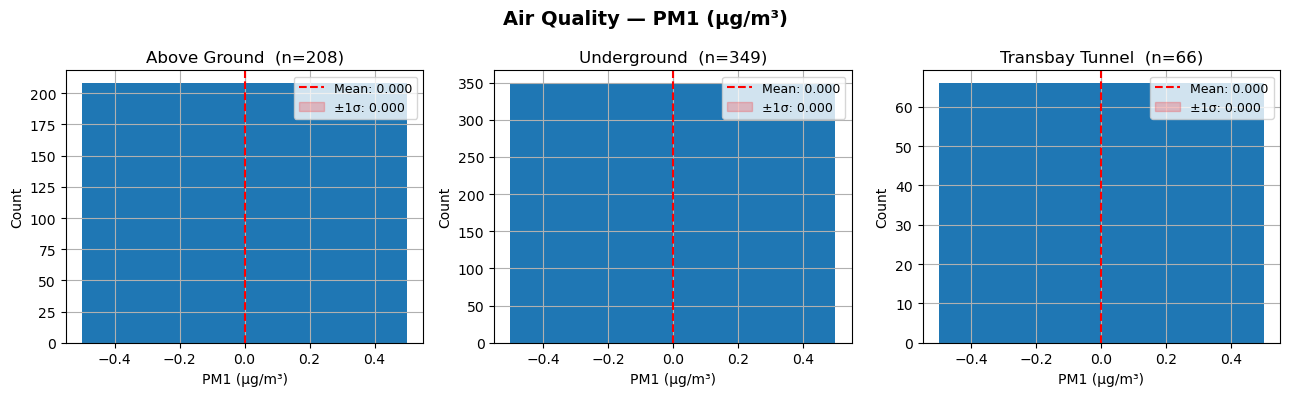

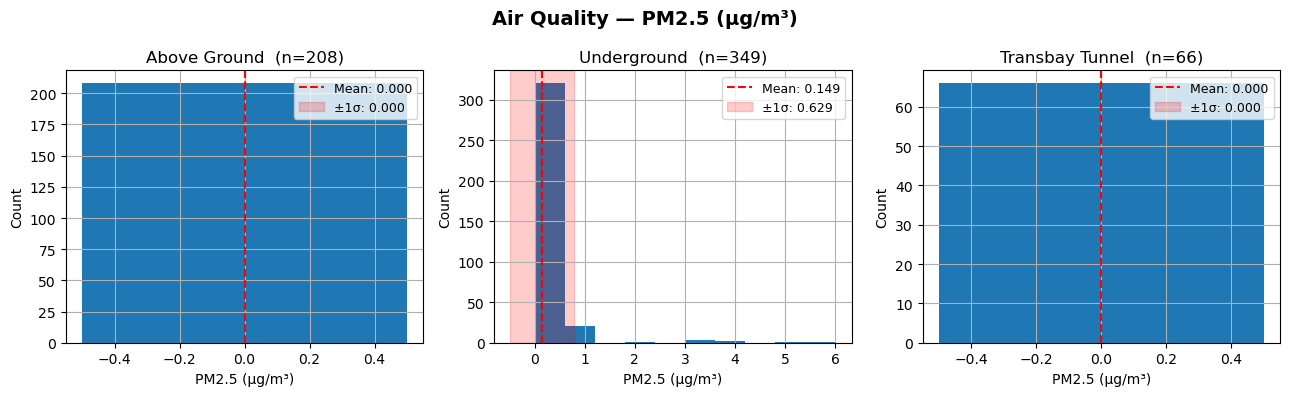

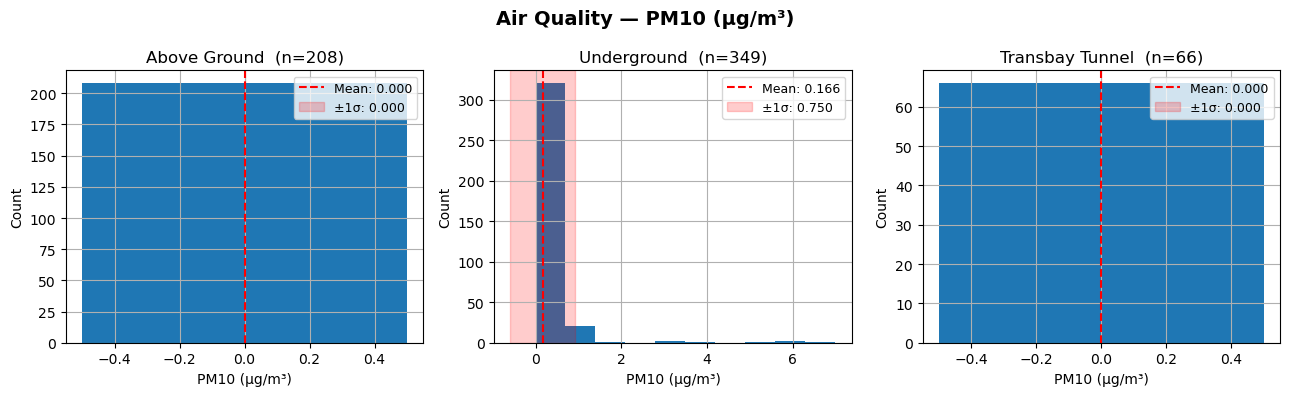


PTH stats:
Segment                 temp_mean        hum_mean      press_mean        voc_mean
------------------------------------------------------------------------------------------
Above Ground         26.77 ±  0.84   33.37 ±  1.87  1010.89 ±  3.31  496723.83 ± 54781.54
Underground          26.49 ±  0.63   35.36 ±  3.93  1013.28 ±  2.75  511324.73 ± 36067.81
Transbay Tunnel      26.94 ±  0.27   35.06 ±  0.44  1015.47 ±  5.23  503595.32 ± 12681.54


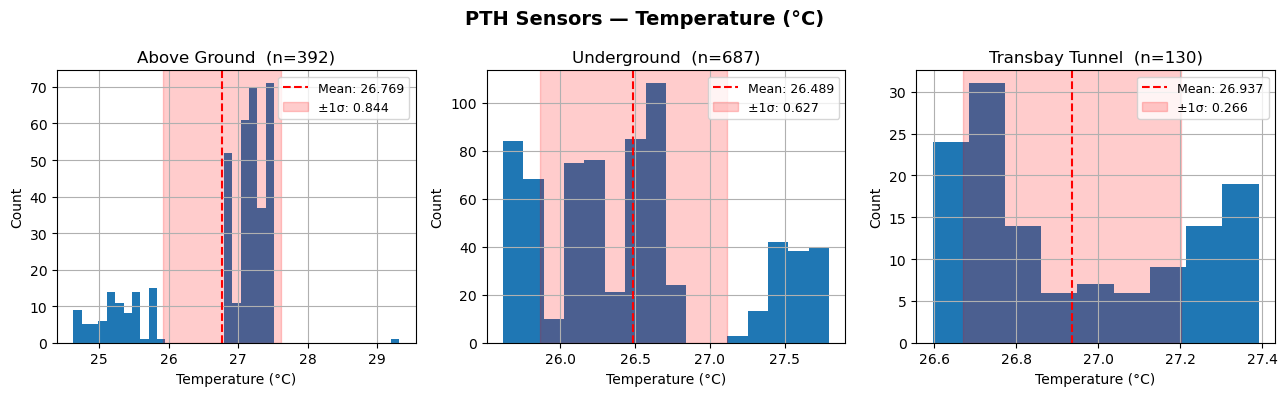

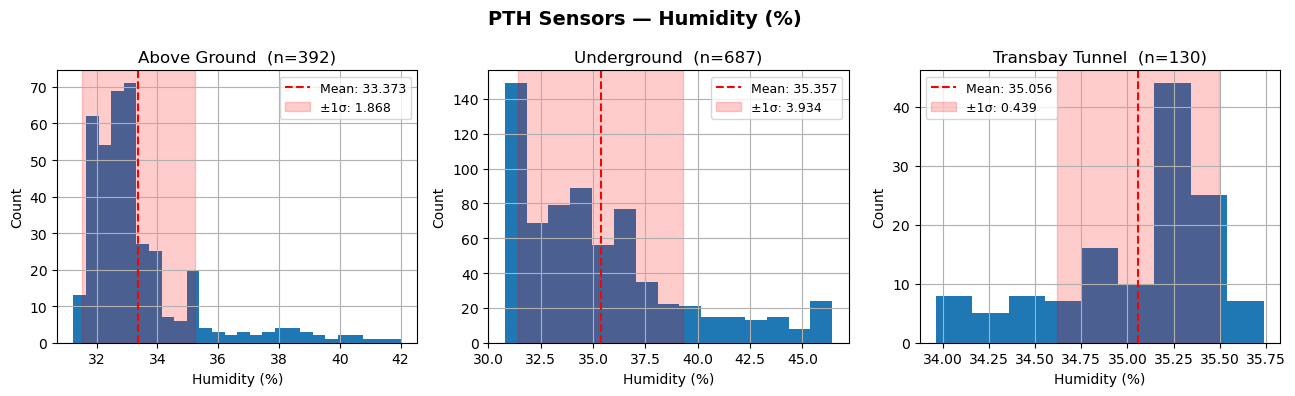

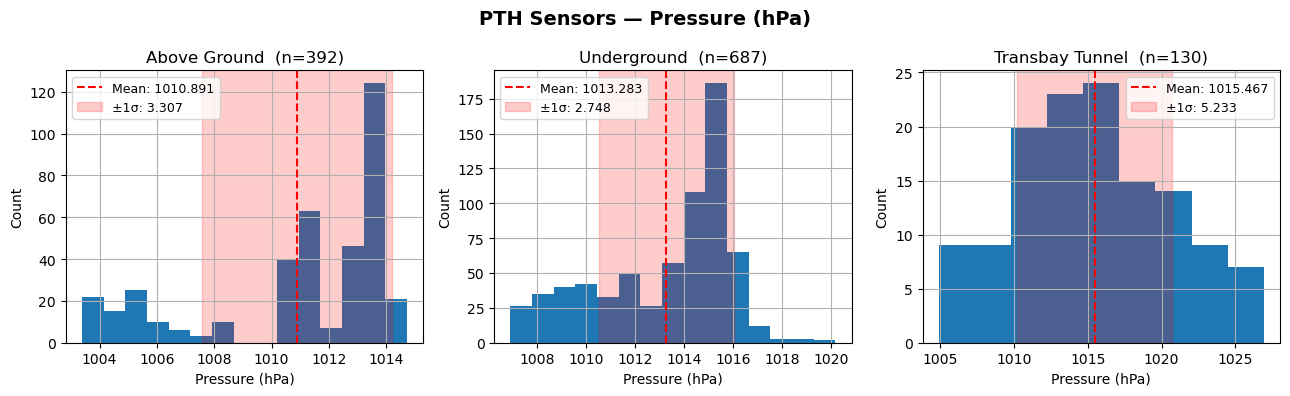

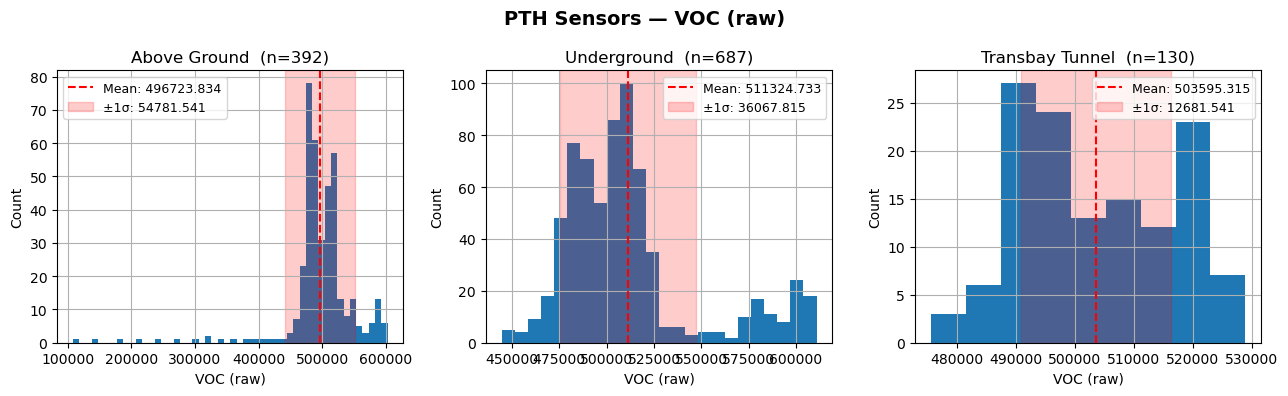

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime

# ── Setup ──────────────────────────────────────────────────────────────────────
t0 = 1777592470.0

def ts(h, m, s):
    base = datetime.datetime(2026, 4, 30, 16, 41, 10)
    return t0 + (datetime.datetime(2026, 4, 30, h, m, s) - base).total_seconds()

segments = [
    (ts(16,41,50), ts(16,44,35), "above"),
    (ts(16,44,35), ts(16,45,40), "underground"),
    (ts(16,45,40), ts(16,46,10), "above"),
    (ts(16,46,10), ts(17, 0,10), "underground"),
    (ts(17, 0,10), ts(17, 4,35), "transbay"),
    (ts(17, 4,35), ts(17, 9,34), "above"),
    (ts(17, 9,34), ts(17,14,10), "underground"),
    (ts(17,14,10), ts(17,19,20), "above"),
    (ts(17,19,21), ts(17,23, 0), "underground"),
]

def classify(t):
    for s, e, cat in segments:
        if s <= t < e:
            return cat
    return "above"

labels = {"above": "Above Ground", "underground": "Underground", "transbay": "Transbay Tunnel"}
cats = ["above", "underground", "transbay"]

def plot_sensor_histograms(df, columns, col_labels, title, filename):
    """One figure per sensor column: 3 subplots (one per segment)."""
    for col, col_label in zip(columns, col_labels):
        fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
        fig.suptitle(f"{title} — {col_label}", fontsize=14, fontweight="bold")
        for ax, cat in zip(axes, cats):
            sub = df[df.segment == cat][col].dropna()
            mean, std = sub.mean(), sub.std()
            ax.hist(sub, bins='auto')
            ax.axvline(mean, color="red", linewidth=1.5, linestyle="--",
                       label=f"Mean: {mean:.3f}")
            ax.axvspan(mean - std, mean + std, alpha=0.2, color="red",
                       label=f"±1σ: {std:.3f}")
            ax.legend(fontsize=9)
            ax.grid()
            ax.set_title(f"{labels[cat]}  (n={len(sub)})")
            ax.set_xlabel(col_label)
            ax.set_ylabel("Count")
        plt.tight_layout()
        plt.savefig(filename.format(col=col), dpi=120)
        plt.show()

# ── Air Quality ────────────────────────────────────────────────────────────────
aq = pd.read_csv("air_quality.csv").sort_values("timestamp").reset_index(drop=True)
aq["segment"] = aq.timestamp.apply(classify)

aq_cols   = ["pm1_mean", "pm25_mean", "pm10_mean"]
aq_labels = ["PM1 (µg/m³)", "PM2.5 (µg/m³)", "PM10 (µg/m³)"]

print("Air Quality stats:")
print(f"{'Segment':<18}", "  ".join(f"{c:>14}" for c in aq_cols))
print("-" * 70)
for cat in cats:
    sub = aq[aq.segment == cat]
    row = f"{labels[cat]:<18}"
    for col in aq_cols:
        row += f"  {sub[col].mean():>6.3f} ± {sub[col].std():>5.3f}"
    print(row)

plot_sensor_histograms(aq, aq_cols, aq_labels, "Air Quality", "hist_aq_{col}.png")

# ── PTH (Pressure / Temperature / Humidity) ───────────────────────────────────
pth = pd.read_csv("pth.csv").sort_values("timestamp").reset_index(drop=True)
pth["segment"] = pth.timestamp.apply(classify)

pth_cols   = ["temp_mean", "hum_mean", "press_mean", "voc_mean"]
pth_labels = ["Temperature (°C)", "Humidity (%)", "Pressure (hPa)", "VOC (raw)"]

print("\nPTH stats:")
print(f"{'Segment':<18}", "  ".join(f"{c:>14}" for c in pth_cols))
print("-" * 90)
for cat in cats:
    sub = pth[pth.segment == cat]
    row = f"{labels[cat]:<18}"
    for col in pth_cols:
        row += f"  {sub[col].mean():>6.2f} ± {sub[col].std():>5.2f}"
    print(row)

plot_sensor_histograms(pth, pth_cols, pth_labels, "PTH Sensors", "hist_pth_{col}.png")

# gps map creation

# ignore beyond here i just wanted to see where the counts come from

Air Quality stats:
Segment                  pm1_mean       pm25_mean       pm10_mean
----------------------------------------------------------------------
Above Ground         0.000 ± 0.000   0.000 ± 0.000   0.000 ± 0.000
Underground          0.000 ± 0.000   0.149 ± 0.629   0.166 ± 0.750
Transbay Tunnel      0.000 ± 0.000   0.000 ± 0.000   0.000 ± 0.000


/tmp/ipykernel_208/168548667.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9)


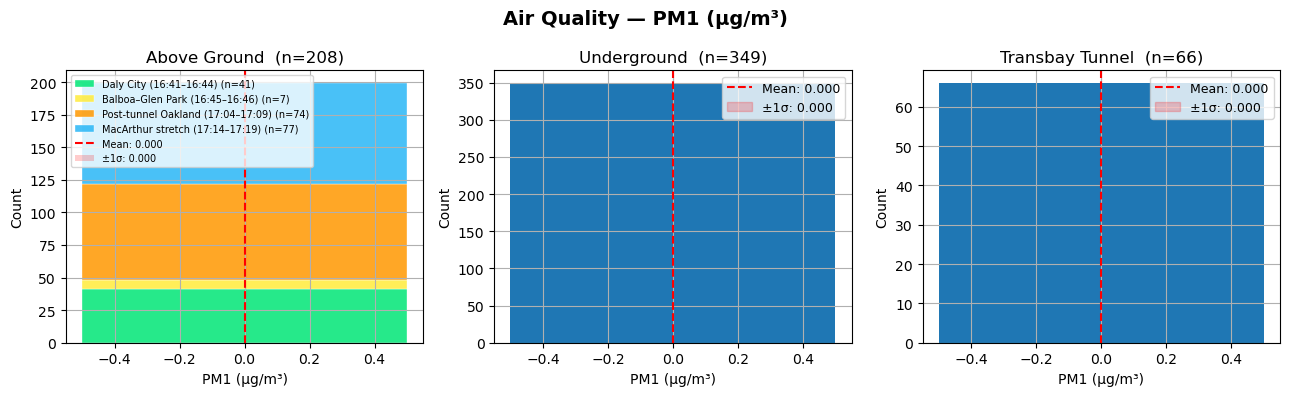

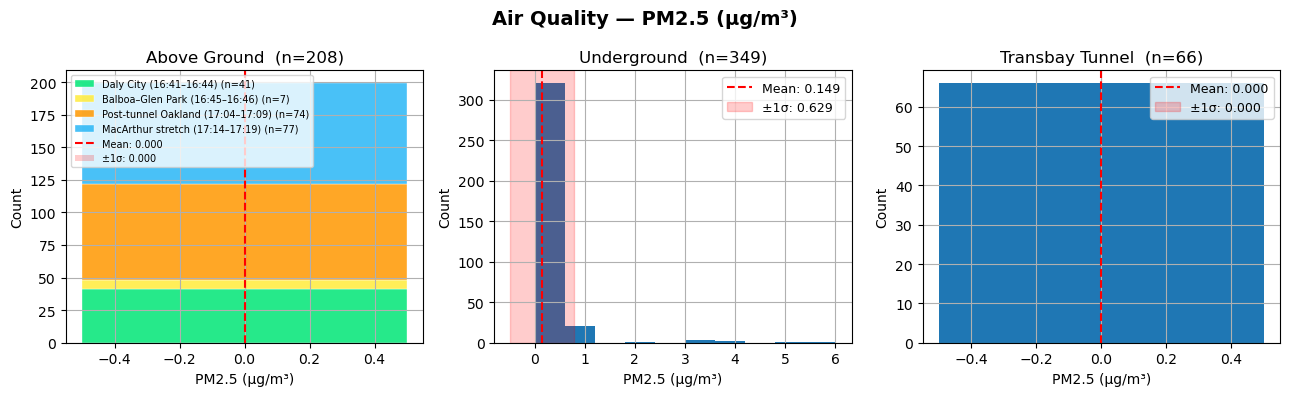

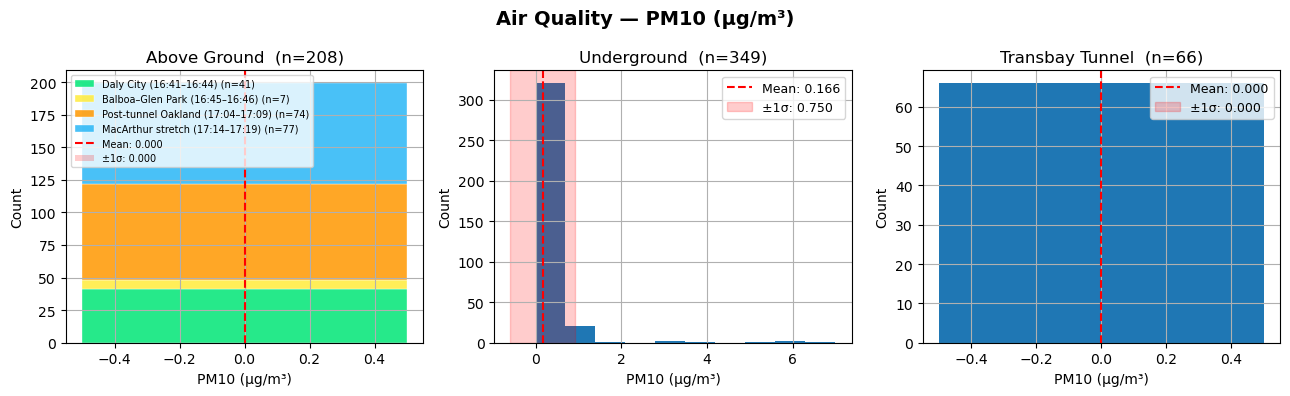


PTH stats:
Segment                 temp_mean        hum_mean      press_mean        voc_mean
------------------------------------------------------------------------------------------
Above Ground         26.77 ±  0.84   33.37 ±  1.87  1010.89 ±  3.31  496723.83 ± 54781.54
Underground          26.49 ±  0.63   35.36 ±  3.93  1013.28 ±  2.75  511324.73 ± 36067.81
Transbay Tunnel      26.94 ±  0.27   35.06 ±  0.44  1015.47 ±  5.23  503595.32 ± 12681.54


/tmp/ipykernel_208/168548667.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9)


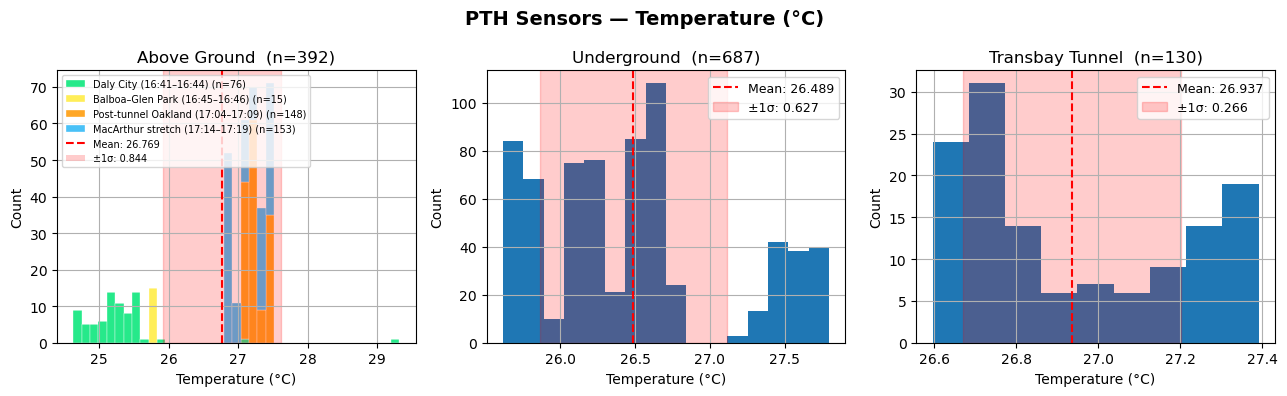

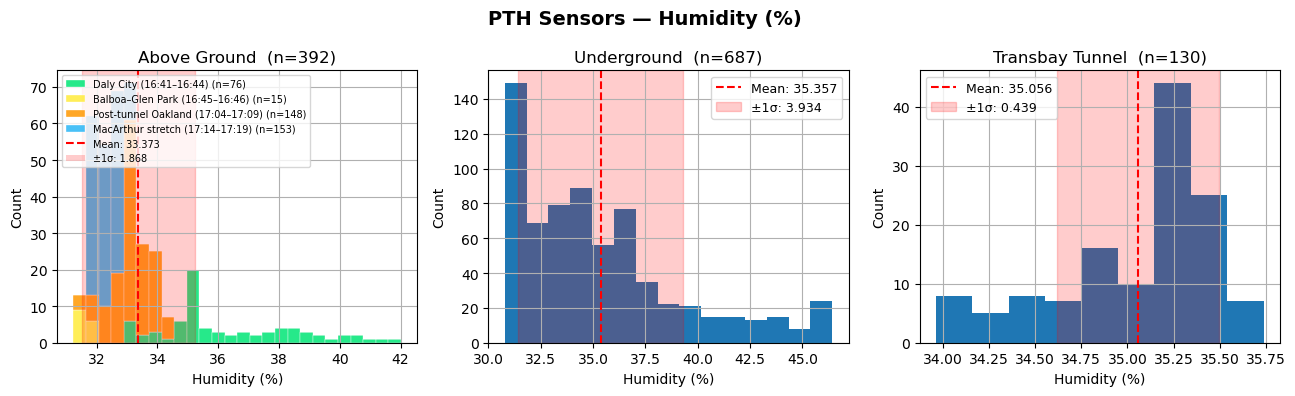

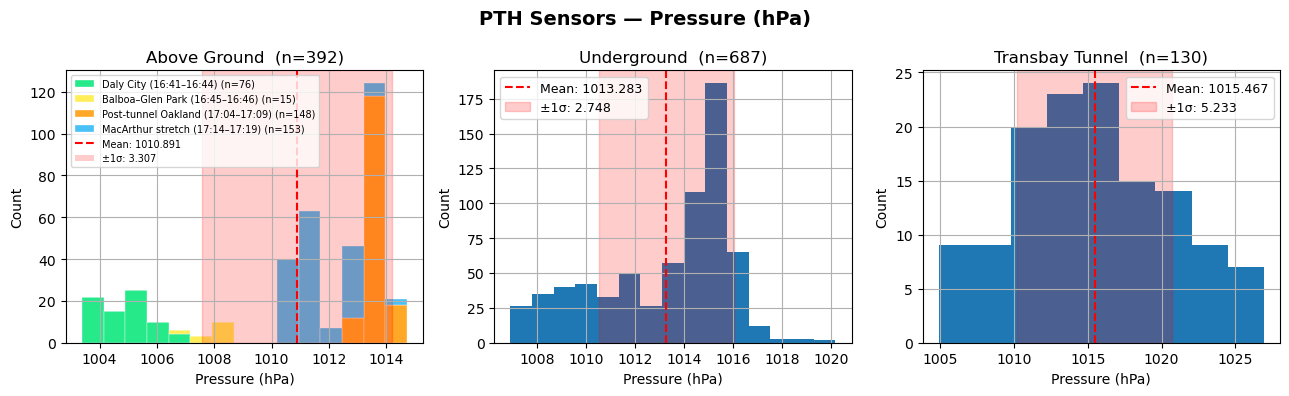

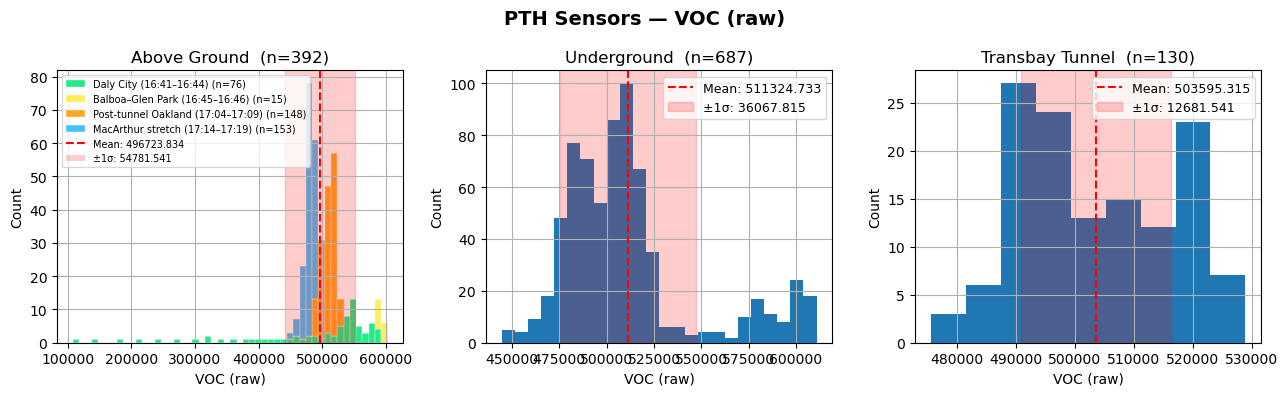

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime

# ── Setup ──────────────────────────────────────────────────────────────────────
t0 = 1777592470.0

def ts(h, m, s):
    base = datetime.datetime(2026, 4, 30, 16, 41, 10)
    return t0 + (datetime.datetime(2026, 4, 30, h, m, s) - base).total_seconds()

segments = [
    (ts(16,41,50), ts(16,44,35), "above"),
    (ts(16,44,35), ts(16,45,40), "underground"),
    (ts(16,45,40), ts(16,46,10), "above"),
    (ts(16,46,10), ts(17, 0,10), "underground"),
    (ts(17, 0,10), ts(17, 4,35), "transbay"),
    (ts(17, 4,35), ts(17, 9,34), "above"),
    (ts(17, 9,34), ts(17,14,10), "underground"),
    (ts(17,14,10), ts(17,19,20), "above"),
    (ts(17,19,21), ts(17,23, 0), "underground"),
]

def classify(t):
    for s, e, cat in segments:
        if s <= t < e:
            return cat
    return "above"

labels = {"above": "Above Ground", "underground": "Underground", "transbay": "Transbay Tunnel"}
cats = ["above", "underground", "transbay"]

def plot_sensor_histograms(df, columns, col_labels, title, filename):
    """One figure per sensor column: 3 subplots (one per segment).
       The 'above' subplot is color-coded by sub-segment."""

    # Define the distinct above-ground windows with labels and colors
    above_windows = [
        (ts(16,41,50), ts(16,44,35), "Daly City (16:41–16:44)",      "#00e676"),
        (ts(16,45,40), ts(16,46,10), "Balboa–Glen Park (16:45–16:46)","#ffeb3b"),
        (ts(17, 4,35), ts(17, 9,34), "Post-tunnel Oakland (17:04–17:09)", "#ff9800"),
        (ts(17,14,10), ts(17,19,20), "MacArthur stretch (17:14–17:19)","#29b6f6"),
    ]

    for col, col_label in zip(columns, col_labels):
        fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
        fig.suptitle(f"{title} — {col_label}", fontsize=14, fontweight="bold")

        for ax, cat in zip(axes, cats):
            sub = df[df.segment == cat][col].dropna()
            mean, std = sub.mean(), sub.std()

            if cat == "above":
                # Stack histograms per sub-window
                window_data = []
                for s, e, wlabel, wcolor in above_windows:
                    mask = (df.timestamp >= s) & (df.timestamp < e) & df[col].notna()
                    wdata = df[mask][col]
                    if len(wdata):
                        window_data.append((wdata, wlabel, wcolor))

                # Use consistent bins across all windows
                bins = np.histogram_bin_edges(sub, bins='auto')
                bottom = np.zeros(len(bins) - 1)
                for wdata, wlabel, wcolor in window_data:
                    counts, _ = np.histogram(wdata, bins=bins)
                    ax.bar(bins[:-1], counts, width=np.diff(bins), bottom=bottom,
                           align='edge', color=wcolor, alpha=0.85,
                           label=f"{wlabel} (n={len(wdata)})", edgecolor='white', linewidth=0.3)
                    bottom += counts
                ax.legend(fontsize=7, loc='upper left')
                # Add mean/std as separate artists so they appear in legend
                from matplotlib.lines import Line2D
                from matplotlib.patches import Patch
                handles, lbls = ax.get_legend_handles_labels()
                handles += [Line2D([0],[0], color='red', linewidth=1.5, linestyle='--'),
                            Patch(facecolor='red', alpha=0.2)]
                lbls += [f"Mean: {mean:.3f}", f"±1σ: {std:.3f}"]
                ax.legend(handles=handles, labels=lbls, fontsize=7, loc='upper left')
            else:
                ax.hist(sub, bins='auto')
                ax.legend(fontsize=9)

            ax.axvline(mean, color="red", linewidth=1.5, linestyle="--",
                       label=f"Mean: {mean:.3f}")
            ax.axvspan(mean - std, mean + std, alpha=0.2, color="red",
                       label=f"±1σ: {std:.3f}")
            if cat != "above":
                ax.legend(fontsize=9)
            ax.grid()
            ax.set_title(f"{labels[cat]}  (n={len(sub)})")
            ax.set_xlabel(col_label)
            ax.set_ylabel("Count")

        plt.tight_layout()
        plt.savefig(filename.format(col=col), dpi=120)
        plt.show()

# ── Air Quality ────────────────────────────────────────────────────────────────
aq = pd.read_csv("air_quality.csv").sort_values("timestamp").reset_index(drop=True)
aq["segment"] = aq.timestamp.apply(classify)

aq_cols   = ["pm1_mean", "pm25_mean", "pm10_mean"]
aq_labels = ["PM1 (µg/m³)", "PM2.5 (µg/m³)", "PM10 (µg/m³)"]

print("Air Quality stats:")
print(f"{'Segment':<18}", "  ".join(f"{c:>14}" for c in aq_cols))
print("-" * 70)
for cat in cats:
    sub = aq[aq.segment == cat]
    row = f"{labels[cat]:<18}"
    for col in aq_cols:
        row += f"  {sub[col].mean():>6.3f} ± {sub[col].std():>5.3f}"
    print(row)

plot_sensor_histograms(aq, aq_cols, aq_labels, "Air Quality", "hist_aq_{col}.png")

# ── PTH (Pressure / Temperature / Humidity) ───────────────────────────────────
pth = pd.read_csv("pth.csv").sort_values("timestamp").reset_index(drop=True)
pth["segment"] = pth.timestamp.apply(classify)

pth_cols   = ["temp_mean", "hum_mean", "press_mean", "voc_mean"]
pth_labels = ["Temperature (°C)", "Humidity (%)", "Pressure (hPa)", "VOC (raw)"]

print("\nPTH stats:")
print(f"{'Segment':<18}", "  ".join(f"{c:>14}" for c in pth_cols))
print("-" * 90)
for cat in cats:
    sub = pth[pth.segment == cat]
    row = f"{labels[cat]:<18}"
    for col in pth_cols:
        row += f"  {sub[col].mean():>6.2f} ± {sub[col].std():>5.2f}"
    print(row)

plot_sensor_histograms(pth, pth_cols, pth_labels, "PTH Sensors", "hist_pth_{col}.png")

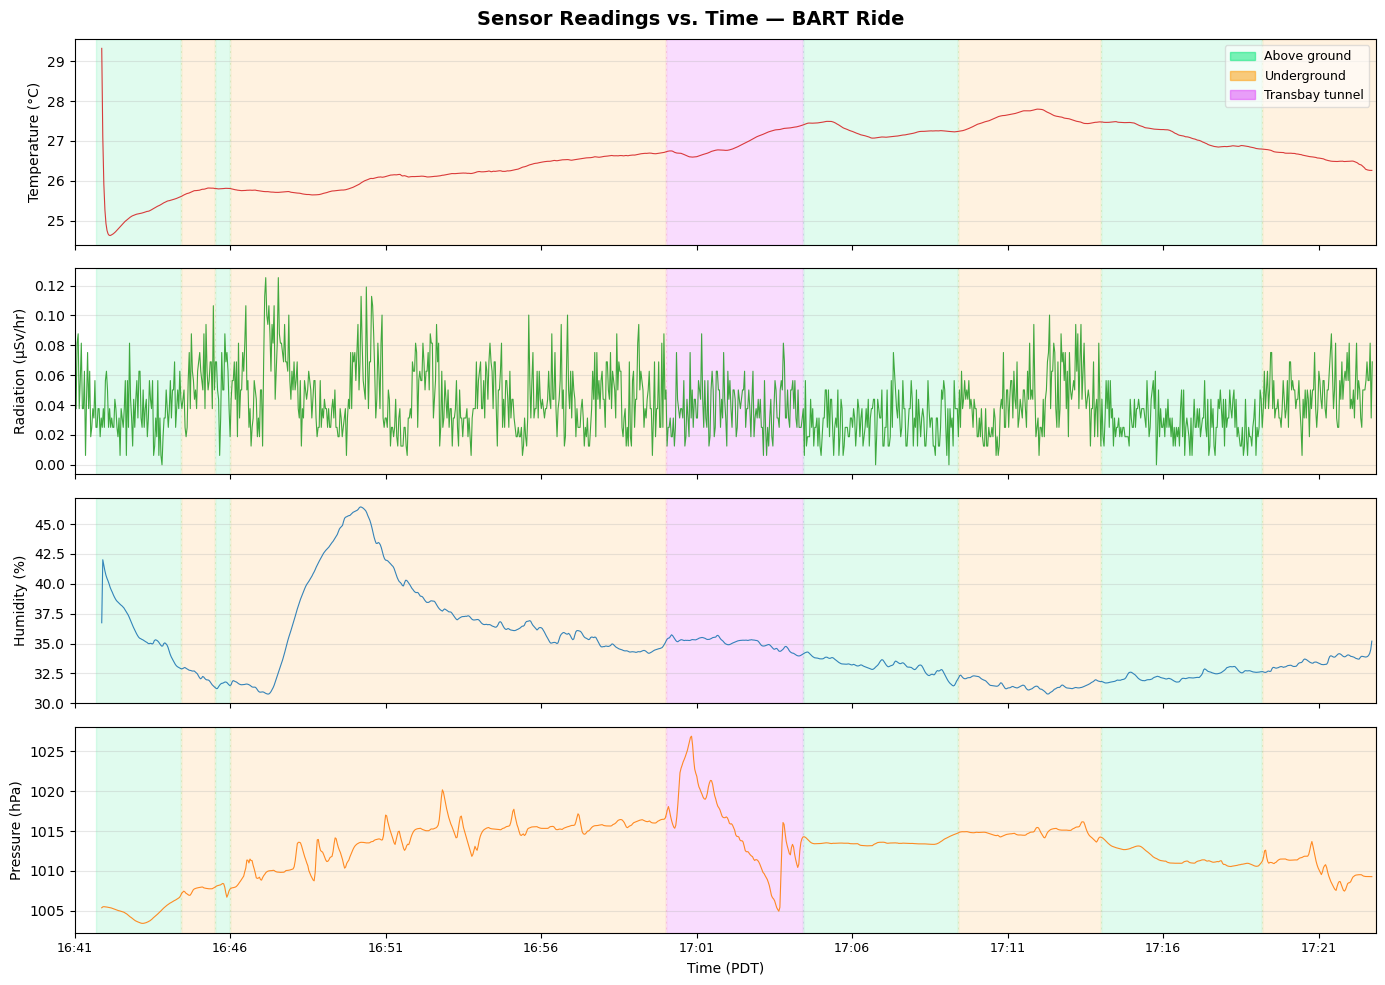

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import datetime

# ── Setup ──────────────────────────────────────────────────────────────────────
t0 = 1777592470.0

def ts(h, m, s):
    base = datetime.datetime(2026, 4, 30, 16, 41, 10)
    return t0 + (datetime.datetime(2026, 4, 30, h, m, s) - base).total_seconds()

segments = [
    (ts(16,41,50), ts(16,44,35), "above"),
    (ts(16,44,35), ts(16,45,40), "underground"),
    (ts(16,45,40), ts(16,46,10), "above"),
    (ts(16,46,10), ts(17, 0,10), "underground"),
    (ts(17, 0,10), ts(17, 4,35), "transbay"),
    (ts(17, 4,35), ts(17, 9,34), "above"),
    (ts(17, 9,34), ts(17,14,10), "underground"),
    (ts(17,14,10), ts(17,19,20), "above"),
    (ts(17,19,21), ts(17,23, 0), "underground"),
]

seg_colors = {"above": "#00e676", "underground": "#ff9800", "transbay": "#e040fb"}
seg_alpha  = {"above": 0.12,      "underground": 0.12,      "transbay": 0.18}

# ── Load data ─────────────────────────────────────────────────────────────────
rad = pd.read_csv("radiation.csv").sort_values("timestamp").reset_index(drop=True)
pth = pd.read_csv("pth.csv").sort_values("timestamp").reset_index(drop=True)

# Convert epoch to elapsed minutes from session start
def to_min(ts_col):
    return (ts_col - t0) / 60

rad["min"] = to_min(rad.timestamp)
pth["min"] = to_min(pth.timestamp)

# Session time bounds
t_start = (ts(16,41,50) - t0) / 60
t_end   = (ts(17,23, 0) - t0) / 60

# ── Segment shading helper ────────────────────────────────────────────────────
def add_segments(ax):
    """Shade background by segment type and draw boundary lines."""
    prev_cat = None
    for s, e, cat in segments:
        s_min = (s - t0) / 60
        e_min = (e - t0) / 60
        ax.axvspan(s_min, e_min, color=seg_colors[cat], alpha=seg_alpha[cat], zorder=0)
        # Draw vertical line at each segment boundary (skip very first)
        if prev_cat is not None and cat != prev_cat:
            ax.axvline(s_min, color="white", linewidth=0.8, linestyle="--", alpha=0.5, zorder=1)
        prev_cat = cat
    ax.set_xlim(t_start, t_end)

# ── X-tick labels: clock time ─────────────────────────────────────────────────
tick_offsets = [0, 5, 10, 15, 20, 25, 30, 35, 40]  # minutes from t0
tick_labels  = []
for m in tick_offsets:
    epoch = t0 + m * 60
    dt = datetime.datetime.fromtimestamp(epoch, tz=datetime.timezone(datetime.timedelta(hours=-7)))
    tick_labels.append(dt.strftime("%H:%M"))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig.suptitle("Sensor Readings vs. Time — BART Ride", fontsize=14, fontweight="bold")

panels = [
    (axes[0], pth,  "temp_mean",  "Temperature (°C)",  "tab:red"),
    (axes[1], rad,  "usv_hr",     "Radiation (µSv/hr)", "tab:green"),
    (axes[2], pth,  "hum_mean",   "Humidity (%)",       "tab:blue"),
    (axes[3], pth,  "press_mean", "Pressure (hPa)",     "tab:orange"),
]

for ax, df, col, ylabel, color in panels:
    add_segments(ax)
    ax.plot(df["min"], df[col], color=color, linewidth=0.8, alpha=0.9)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(axis="y", alpha=0.3)
    ax.set_xticks(tick_offsets)
    ax.set_xticklabels([])

# Only show x-tick labels on bottom panel
axes[-1].set_xticklabels(tick_labels, fontsize=9)
axes[-1].set_xlabel("Time (PDT)", fontsize=10)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color=seg_colors["above"],       alpha=0.5, label="Above ground"),
    mpatches.Patch(color=seg_colors["underground"], alpha=0.5, label="Underground"),
    mpatches.Patch(color=seg_colors["transbay"],    alpha=0.5, label="Transbay tunnel"),
]
axes[0].legend(handles=legend_patches, loc="upper right", fontsize=9, framealpha=0.6)

plt.tight_layout()
plt.show()